In [1]:
from hydra import initialize, compose
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.patches import Patch
import re
from rdkit import Chem
from rdkit.Chem import AllChem
from collections import defaultdict

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

def find_between_rules(s):
    match = re.search(r'_rules_(.+?)_rules_', s)
    return match.group(1) if match else None

In [2]:
cutoff_date = 2015
pub = pl.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub = pub.explode("publication_dates")
pub = pub.group_by("id").agg(pl.col("publication_dates").min()).filter(pl.col("publication_dates") >= cutoff_date).rename({"publication_dates": "pub_date"})
tot_pub_rxns = pub.shape[0]
print(f"Total reactions with publication date >= {cutoff_date}: {tot_pub_rxns:,}")
pub.head()

Total reactions with publication date >= 2015: 4,466


id,pub_date
str,i32
"""1b5935434633c448139e46d3de8998…",2016
"""7f89b2050d68b53862edbe5b76718c…",2022
"""777665fe9f90698aaa738b27770c2b…",2015
"""7060b0881b4f6df3b3c9ba2aefcbe7…",2023
"""8d0c3a4d587652f729e06e711611da…",2017


In [ ]:
metrics = []
for fn in (Path(cfg.interim_data) / "std_pickaxe_rxns").glob("*.parquet"):
    _name = find_between_rules(fn.stem)
    suffix = "_direct_mcsa_only" if "direct_mcsa_only" in fn.stem else ""

    maps = pl.read_parquet(
        Path(cfg.raw_data) / "mappings" / f"mapped_known_reactions_x_{_name}_rules_before_{cutoff_date}{suffix}.parquet"
    )
    _name = f"{_name}{suffix}"

    pred = pl.read_parquet(fn)
    _n_pub_recovered = maps.join(pub, left_on="rxn_id", right_on="id", how="inner").shape[0]
    metrics.append(
        {
            "name": _name,
            "num_rxns": len(pred),
            "num_unique_rxns": pred["std_rxn"].n_unique(),
            "num_pub_rxns": _n_pub_recovered,
            "frac_pub_rxns": _n_pub_recovered / tot_pub_rxns,
            "fn": fn,
        }
    )

metrics.append(
    {
        "name": "rc_plus_0",
        "num_rxns": 7666721,
        "num_unique_rxns": 7666721,
        "num_pub_rxns": 2690,
        "frac_pub_rxns": 2690 / tot_pub_rxns,
         "fn": None,
    }
)

metrics.append(
    {
        "name": "mechinferred_dt_059_direct_mcsa_only",
        "num_rxns": 47_327,
        "num_unique_rxns": 47_327,
        "num_pub_rxns": 1_183,
        "frac_pub_rxns": 1_183 / tot_pub_rxns,
         "fn": None,
    }
)

metrics.append(
    {
        "name": "mechinferred_dt_035_direct_mcsa_only",
        "num_rxns": 40_109,
        "num_unique_rxns": 40_109,
        "num_pub_rxns": 780,
        "frac_pub_rxns": 780 / tot_pub_rxns,
         "fn": None,
    }
)

metrics = pl.DataFrame(metrics)
metrics.head()

shape: (18, 6)
┌───────────────────┬──────────┬─────────────────┬──────────────┬───────────────┬──────────────────┐
│ name              ┆ num_rxns ┆ num_unique_rxns ┆ num_pub_rxns ┆ frac_pub_rxns ┆ fn               │
│ ---               ┆ ---      ┆ ---             ┆ ---          ┆ ---           ┆ ---              │
│ str               ┆ i64      ┆ i64             ┆ i64          ┆ f64           ┆ object           │
╞═══════════════════╪══════════╪═════════════════╪══════════════╪═══════════════╪══════════════════╡
│ rc_plus_2         ┆ 73707    ┆ 73702           ┆ 1612         ┆ 0.360949      ┆ /home/stef/cgr/d │
│                   ┆          ┆                 ┆              ┆               ┆ ata/interim/st…  │
│ rc_plus_1         ┆ 132439   ┆ 131469          ┆ 2048         ┆ 0.458576      ┆ /home/stef/cgr/d │
│                   ┆          ┆                 ┆              ┆               ┆ ata/interim/st…  │
│ mechinferred_dt_9 ┆ 750533   ┆ 747874          ┆ 2518         ┆ 0.563815  

In [29]:
metrics.filter(pl.col("name") == "mechinferred_dt_932")

name,num_rxns,num_unique_rxns,num_pub_rxns,frac_pub_rxns,fn
str,i64,i64,i64,f64,object
"""mechinferred_dt_932""",726073,723410,2519,0.564039,/home/stef/cgr/data/interim/std_pickaxe_rxns/1_steps_after_2015_cpds_rules_mechinferred_dt_932_rules_before_2015_w_coreactants_aplusb_True.parquet


In [30]:
2519/726073

0.0034693481233980606

In [15]:
Rs = [0, 1, 2, 3, 4]
dts = ['932', '069', '021', '009', '005']
dts_dmo = ['961', '244', '106', '059', '035']
others = ['mechinformed', 'rdchiral', 'imt']
mechinferred_template_sizes = defaultdict(list)
rcr_template_sizes = defaultdict(list)
dmo_template_sizes = defaultdict(list)
bad_rules = {'rcr': set(), 'mechinferred': set()}
rcr_rules = []
other_rules = []
other_template_sizes = defaultdict(list)

for dt in dts:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}.csv",
    )
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        mechinferred_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for dt in dts_dmo:
    df = pl.read_csv(
        Path(cfg.rules) / f"mechinferred_dt_{dt}_rules_before_{cutoff_date}_direct_mcsa_only.csv",
    )
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        dmo_template_sizes[dt].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for R in Rs:
    if R == 0:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_0_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            Path(cfg.rules) / f"rc_plus_{R}_rules_before_{cutoff_date}.csv",
        )
    rcr_rules.append(df)
    for row in df.iter_rows(named=True):
        sma = row["smarts"]
        rxn = AllChem.ReactionFromSmarts(sma)
        rcr_template_sizes[R].append(
            sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
        )

for other in others:
    if other == 'imt':
        df = pl.read_csv(
            Path(cfg.rules) / f"imt_rules_before_{cutoff_date}.csv",
        )
    else:
        df = pl.read_csv(
            Path(cfg.rules) / f"{other}_rules_before_{cutoff_date}.csv",
        )
    other_rules.append(df)
    for row in df.iter_rows(named=True):
            sma = row["smarts"]
            rxn = AllChem.ReactionFromSmarts(sma)
            other_template_sizes[other].append(
                sum(rct.GetNumAtoms() for rct in rxn.GetReactants())
            )

median_template_size = {}

for name in metrics["name"].unique().to_list():
    vals = None

    if name.startswith("mechinferred_dt_") and "direct_mcsa_only" not in name:
        dt = name.split("_")[-1]
        vals = mechinferred_template_sizes.get(dt, [])
    elif name.startswith("rc_plus_"):
        R = int(name.split("_")[-1])
        vals = rcr_template_sizes.get(R, [])
    elif name.startswith("mechinferred_dt_") and "direct_mcsa_only" in name:
        dt = name.split("_")[2]
        vals = dmo_template_sizes.get(dt, [])
    else:
        vals = other_template_sizes.get(name, [])

    median_template_size[name] = pl.Series(vals).median() if vals else None

median_template_size


{'rc_plus_0': 5.0,
 'mechinferred_dt_009': 34.0,
 'imt': 3.0,
 'mechinferred_dt_106_direct_mcsa_only': 34.0,
 'rc_plus_2': 13.0,
 'mechinferred_dt_961_direct_mcsa_only': 4.0,
 'mechinferred_dt_932': 4.0,
 'rc_plus_3': 17.0,
 'rc_plus_4': 21.0,
 'mechinferred_dt_035_direct_mcsa_only': 49.0,
 'mechinferred_dt_069': 18.0,
 'mechinferred_dt_021': 30.0,
 'rc_plus_1': 8.0,
 'mechinferred_dt_059_direct_mcsa_only': 38.0,
 'mechinferred_dt_005': 40.0,
 'rdchiral': 10.0,
 'mechinferred_dt_244_direct_mcsa_only': 19.0,
 'mechinformed': 7.0}

In [16]:
# Plot cfg

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

exp_labels = {
    'mechinformed': "Distilled",
    'mechinferred_dt_932': "Learned >0.932",
    'mechinferred_dt_069': "Learned >0.069",
    'mechinferred_dt_021': "Learned >0.021",
    'mechinferred_dt_009': "Learned >0.009",
    'mechinferred_dt_005': "Learned >0.005",
    'mechinferred_dt_961_direct_mcsa_only': "Learned >0.961 (direct MCSA only)",
    'mechinferred_dt_244_direct_mcsa_only': "Learned >0.244 (direct MCSA only)",
    'mechinferred_dt_106_direct_mcsa_only': "Learned >0.106 (direct MCSA only)",
    'mechinferred_datat_059_direct_mcsa_only': "Learned >0.059 (direct MCSA only)",
    'mechinferred_dt_035_direct_mcsa_only': "Learned >0.035 (direct MCSA only)",
    'rc_plus_0': "RC + 0",
    'rc_plus_1': "RC + 1",
    'rc_plus_2': "RC + 2",
    'rc_plus_3': "RC + 3",
    'rc_plus_4': "RC + 4",
    'imt': "Pathway-level clustering",
    'rdchiral': "RDChiral",
}

colors = {
    'mechinformed': matplotlib.colors.to_rgba("green"),
    'mechinferred_dt_932': matplotlib.colors.to_rgba("purple", alpha=0.3),
    'mechinferred_dt_069': matplotlib.colors.to_rgba("purple", alpha=0.45),
    'mechinferred_dt_021': matplotlib.colors.to_rgba("purple", alpha=0.6),
    'mechinferred_dt_009': matplotlib.colors.to_rgba("purple", alpha=0.85),
    'mechinferred_dt_005': matplotlib.colors.to_rgba("purple", alpha=1.0),
    'mechinferred_dt_961_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.3),
    'mechinferred_dt_244_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.45),
    'mechinferred_dt_106_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.6),
    'mechinferred_datat_059_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=0.85),
    'mechinferred_dt_035_direct_mcsa_only': matplotlib.colors.to_rgba("red", alpha=1.0),
    'rc_plus_0': matplotlib.colors.to_rgba("black", alpha=0.3),
    'rc_plus_1': matplotlib.colors.to_rgba("black", alpha=0.45),
    'rc_plus_2': matplotlib.colors.to_rgba("black", alpha=0.6),
    'rc_plus_3': matplotlib.colors.to_rgba("black", alpha=0.85),
    'rc_plus_4': matplotlib.colors.to_rgba("black", alpha=1.0),
    'imt': matplotlib.colors.to_rgba("darkorange"),
    'rdchiral': matplotlib.colors.to_rgba("blue"),
}

exp_names = list(exp_labels.keys())

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
]

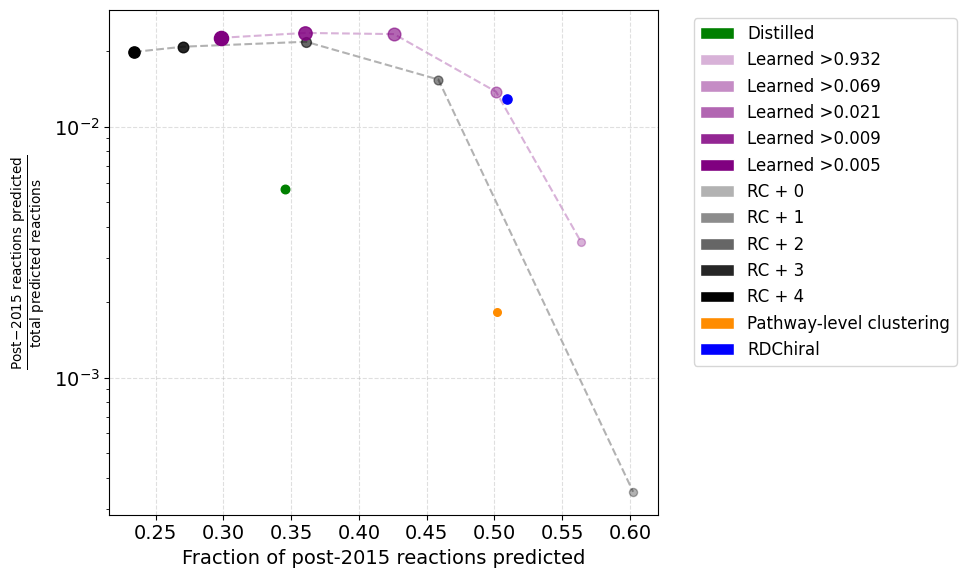

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24

legend_elements = [
    Patch(facecolor=col, edgecolor='w', label=exp_labels[name])
    for name, col in colors.items()
    if "direct_mcsa_only" not in name
]

# collect grouped points for connecting lines
mechinferred_data = []
rcr_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    if "direct_mcsa_only" in name:
        continue
    
    if name not in exp_labels:
        continue

    x = row["frac_pub_rxns"]
    y = row["num_pub_rxns"] / row["num_rxns"]

    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    if name.startswith("mechinferred_dt_"):
        mechinferred_data.append((x, y))
    elif name.startswith("rc_plus_"):
        rcr_data.append((x, y))

    ax.scatter(
        x,
        y,
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

# connect purple dots (mechinferred)
if mechinferred_data:
    mechinferred_data = sorted(mechinferred_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in mechinferred_data],
        [p[1] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect black dots (rc_plus)
if rcr_data:
    rcr_data = sorted(rcr_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in rcr_data],
        [p[1] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

ax.set_xlabel(f"Fraction of post-{cutoff_date} reactions predicted")
ax.set_ylabel(
    rf"$\frac{{\mathrm{{Post\!-\!{cutoff_date}\ reactions\ predicted}}}}{{\mathrm{{total\ predicted\ reactions}}}}$"
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(Path(cfg.figures) / f"after_{cutoff_date}_generative_performance.svg")
plt.show()


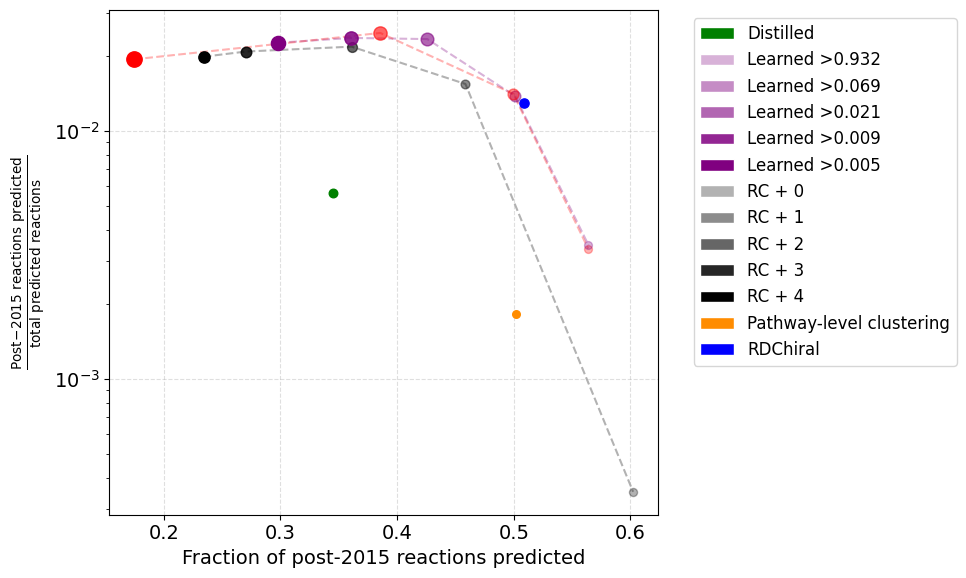

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
dot_slope = 2
dot_intercept = 24

# collect grouped points for connecting lines
mechinferred_data = []
rcr_data = []
dmo_data = []

for row in metrics.iter_rows(named=True):
    name = row["name"]
    if name not in exp_labels:
        continue

    x = row["frac_pub_rxns"]
    y = row["num_pub_rxns"] / row["num_rxns"]

    template_size = median_template_size.get(name)
    marker_size = (
        dot_slope * template_size + dot_intercept
        if template_size is not None
        else dot_intercept
    )

    if name.startswith("mechinferred_dt_") and "direct_mcsa_only" not in name:
        mechinferred_data.append((x, y))
    elif name.startswith("rc_plus_"):
        rcr_data.append((x, y))
    elif "direct_mcsa_only" in name:
        dmo_data.append((x, y))

    ax.scatter(
        x,
        y,
        color=colors[name],
        s=marker_size,
        label=exp_labels[name],
        zorder=3,
    )

# connect purple dots (mechinferred)
if mechinferred_data:
    mechinferred_data = sorted(mechinferred_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in mechinferred_data],
        [p[1] for p in mechinferred_data],
        color="purple",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

# connect black dots (rc_plus)
if rcr_data:
    rcr_data = sorted(rcr_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in rcr_data],
        [p[1] for p in rcr_data],
        color="black",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

if dmo_data:
    dmo_data = sorted(dmo_data, key=lambda p: p[0])
    ax.plot(
        [p[0] for p in dmo_data],
        [p[1] for p in dmo_data],
        color="red",
        linestyle="--",
        alpha=0.3,
        zorder=1,
    )

ax.set_xlabel(f"Fraction of post-{cutoff_date} reactions predicted")
ax.set_ylabel(
    rf"$\frac{{\mathrm{{Post\!-\!{cutoff_date}\ reactions\ predicted}}}}{{\mathrm{{total\ predicted\ reactions}}}}$"
)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
plt.show()
